# Project 4: Energy Market Analytics & Price Prediction

This notebook demonstrates a complete workflow for **energy market price prediction** using sample datasets.

The project uses:
- electricity market price data
- electricity demand data
- weather data

The target is to predict the **next-hour electricity price**.

A **Gradient Boosting Regressor** is used in this notebook. This model is a good choice for teaching because it is more powerful than simple linear models.

Tje notebook demonstrates a full market price forecasting pipeline:
- loading and cleaning multiple datasets
- merging demand and weather with price data
- creating time, lag, and rolling features
- building a baseline forecast
- training a Gradient Boosting model
- evaluating and visualizing results

## Step 1. Import the Python libraries

In this first step, the Python libraries that will be used throughout the notebook are imported. These libraries are needed for data manipulation, visualization, machine learning, and evaluation. The selected libraries are widely used in practical data science projects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 2. Load the datasets

In this step, the three CSV datasets are loaded. In real-world energy projects, market price data, demand data, and weather data are often collected from different sources and must be combined before modeling.


In [2]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

price_df = pd.read_csv(f"{BASE_URL}/sample_energy_market_prices.csv")
demand_df = pd.read_csv(f"{BASE_URL}/sample_market_demand.csv")
weather_df = pd.read_csv(f"{BASE_URL}/sample_market_weather.csv")


## Step 3. Display the first rows and basic information

In this step, the first rows and structural information of the datasets are displayed. This makes it possible to verify that the files were loaded correctly and to inspect the available columns and their data types.


In [3]:
print("PRICE DATA")
print(price_df.head())
print(price_df.info())

print("\nDEMAND DATA")
print(demand_df.head())
print(demand_df.info())

print("\nWEATHER DATA")
print(weather_df.head())
print(weather_df.info())


PRICE DATA
             timestamp  price_eur_mwh
0  2023-01-01 00:00:00      52.483571
1  2023-01-01 01:00:00      51.896869
2  2023-01-01 02:00:00      58.238443
3  2023-01-01 03:00:00      64.686217
4  2023-01-01 04:00:00      57.489487
<class 'pandas.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      2160 non-null   str    
 1   price_eur_mwh  2160 non-null   float64
dtypes: float64(1), str(1)
memory usage: 33.9 KB
None

DEMAND DATA
             timestamp   demand_mw
0  2023-01-01 00:00:00   68.885420
1  2023-01-01 01:00:00   83.146531
2  2023-01-01 02:00:00   87.661709
3  2023-01-01 03:00:00   97.259355
4  2023-01-01 04:00:00  105.805407
<class 'pandas.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2160 non-null   str   

## Step 4. Convert the timestamp columns to datetime format

In this step, the timestamp columns are converted to datetime format. This is required because time-based processing such as sorting, merging, resampling, and extracting time features depends on proper datetime values.


In [4]:
price_df["timestamp"] = pd.to_datetime(price_df["timestamp"])
demand_df["timestamp"] = pd.to_datetime(demand_df["timestamp"])
weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])


## Step 5. Sort the datasets chronologically

In this step, the datasets are sorted by time. Time series data must be ordered correctly before performing lag operations or building forecasting models.


In [5]:
price_df = price_df.sort_values("timestamp").reset_index(drop=True)
demand_df = demand_df.sort_values("timestamp").reset_index(drop=True)
weather_df = weather_df.sort_values("timestamp").reset_index(drop=True)


## Step 6. Remove duplicate timestamps

In this step, duplicate timestamps are removed. Duplicate records can create incorrect results during merging and can distort the model training process.


In [6]:
price_df = price_df.drop_duplicates(subset="timestamp")
demand_df = demand_df.drop_duplicates(subset="timestamp")
weather_df = weather_df.drop_duplicates(subset="timestamp")


## Step 7. Check missing values

In this step, missing values are counted in each dataset. Missing values are common in energy and weather data, so they should be identified before the datasets are merged.


In [7]:
print("Missing values in price data:")
print(price_df.isna().sum())

print("\nMissing values in demand data:")
print(demand_df.isna().sum())

print("\nMissing values in weather data:")
print(weather_df.isna().sum())


Missing values in price data:
timestamp        0
price_eur_mwh    0
dtype: int64

Missing values in demand data:
timestamp    0
demand_mw    0
dtype: int64

Missing values in weather data:
timestamp      0
temperature    0
dtype: int64


## Step 8. Set the timestamp as the index

In this step, the timestamp column becomes the index of each dataset. This makes time-based operations such as resampling and alignment easier to perform.


In [8]:
price_df = price_df.set_index("timestamp")
demand_df = demand_df.set_index("timestamp")
weather_df = weather_df.set_index("timestamp")


## Step 9. Resample the datasets to hourly frequency

In this step, the datasets are resampled to hourly frequency. This is useful because forecasting models work best when all variables follow the same time interval. The sample data is already hourly, but this step demonstrates a standard operation used in real projects.


In [9]:
price_df = price_df.resample("h").mean()
demand_df = demand_df.resample("h").mean()
weather_df = weather_df.resample("h").mean()


## Step 10. Merge price, demand, and weather into one dataset

In this step, the three datasets are merged by timestamp. This produces one table where each hour contains price, demand, and weather variables together.


In [10]:
df = price_df.join(demand_df, how="inner").join(weather_df, how="inner")
print(df.head())
print("\nMerged dataset shape:", df.shape)


                     price_eur_mwh   demand_mw  temperature
timestamp                                                  
2023-01-01 00:00:00      52.483571   68.885420    10.072765
2023-01-01 01:00:00      51.896869   83.146531     9.635810
2023-01-01 02:00:00      58.238443   87.661709    16.273548
2023-01-01 03:00:00      64.686217   97.259355     4.788738
2023-01-01 04:00:00      57.489487  105.805407     6.359537

Merged dataset shape: (2160, 3)


## Step 11. Handle missing values after merging

In this step, missing values are handled using forward fill and backward fill. For time series data, this approach is often more appropriate than filling with a global average because it preserves local continuity in the series.


In [11]:
print("Missing values before filling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())


Missing values before filling:
price_eur_mwh    0
demand_mw        0
temperature      0
dtype: int64

Missing values after filling:
price_eur_mwh    0
demand_mw        0
temperature      0
dtype: int64


## Step 12. Visualize the target price series

In this step, the electricity price series is plotted. Visual inspection helps reveal patterns such as daily cycles, volatility, and unusual price spikes.


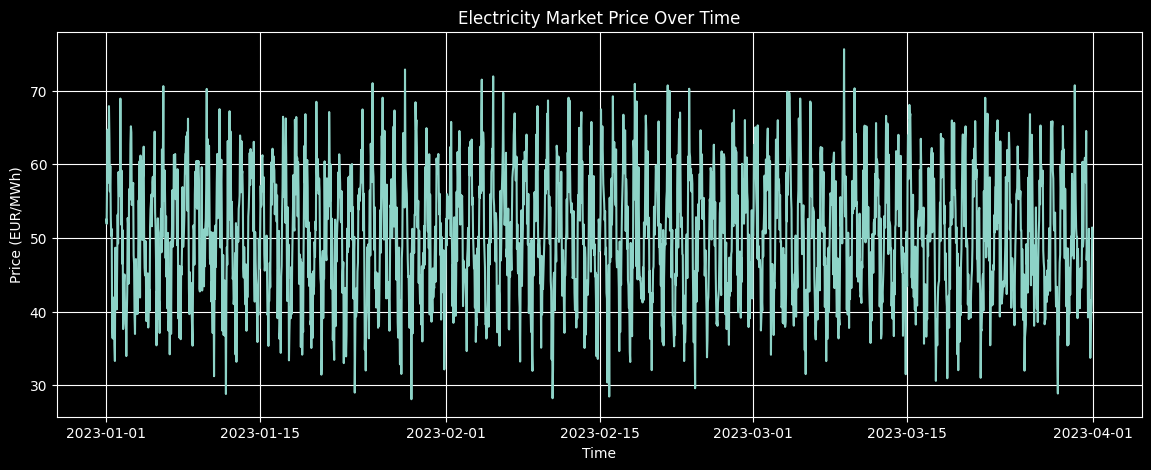

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["price_eur_mwh"])
plt.title("Electricity Market Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.grid(True)
plt.show()


## Step 13. Create time-based features

In this step, calendar features are extracted from the timestamp. Electricity prices are strongly affected by the hour of the day, the day of the week, and the season or month.


In [13]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


## Step 14. Create cyclical time features

In this step, the hour and day-of-week variables are transformed into sine and cosine representations. This is useful because these variables are cyclical. For example, hour 23 and hour 0 are close in time, but their raw numeric values are far apart.


In [14]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)


## Step 15. Create lag features from previous prices and demand

In this step, lag features are created. Previous values are among the most useful predictors in market forecasting because energy prices and demand often show temporal dependence.

The selected lags are:
- previous 1 hour
- previous 24 hours
- previous 168 hours, which represents the same hour one week earlier


In [15]:
df["price_lag_1"] = df["price_eur_mwh"].shift(1)
df["price_lag_24"] = df["price_eur_mwh"].shift(24)
df["price_lag_168"] = df["price_eur_mwh"].shift(168)

df["demand_lag_1"] = df["demand_mw"].shift(1)
df["demand_lag_24"] = df["demand_mw"].shift(24)


## Step 16. Create rolling statistics

In this step, rolling averages are calculated. These features summarize recent behavior and help the model capture short-term and medium-term market trends. The shift is applied first so that only past information is used.


In [16]:
df["price_roll_mean_24"] = df["price_eur_mwh"].shift(1).rolling(window=24).mean()
df["price_roll_std_24"] = df["price_eur_mwh"].shift(1).rolling(window=24).std()

df["demand_roll_mean_24"] = df["demand_mw"].shift(1).rolling(window=24).mean()


## Step 17. Create the forecasting target

In this step, the target variable is defined as the electricity price one hour ahead. This means the model will use current and past information to forecast the next-hour market price.


In [17]:
df["target_price_next_hour"] = df["price_eur_mwh"].shift(-1)


## Step 18. Remove rows with missing values caused by shifting

In this step, rows with missing values are removed. Lag features, rolling calculations, and target shifting naturally create empty rows at the beginning or end of the dataset.


In [18]:
df = df.dropna()
print("Final dataset shape:", df.shape)
print(df.head())


Final dataset shape: (1991, 20)
                     price_eur_mwh  demand_mw  temperature  hour  day_of_week  \
timestamp                                                                       
2023-01-08 00:00:00      48.773059  86.955378    15.778521     0            6   
2023-01-08 01:00:00      48.819510  89.172505    11.379416     1            6   
2023-01-08 02:00:00      50.552428  79.739822    13.349893     2            6   
2023-01-08 03:00:00      52.992016  85.141872     6.584943     3            6   
2023-01-08 04:00:00      58.274745  74.821263     8.426127     4            6   

                     month  is_weekend  hour_sin  hour_cos   dow_sin  dow_cos  \
timestamp                                                                       
2023-01-08 00:00:00      1           1  0.000000  1.000000 -0.781831  0.62349   
2023-01-08 01:00:00      1           1  0.258819  0.965926 -0.781831  0.62349   
2023-01-08 02:00:00      1           1  0.500000  0.866025 -0.781831  0.6234

## Step 19. Define the model input features and target

In this step, the feature columns and the target variable are separated. The features include price history, demand history, weather variables, and calendar-based variables.


In [20]:
feature_columns = [
    "demand_mw",
    "temperature",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "price_lag_1",
    "price_lag_24",
    "price_lag_168",
    "demand_lag_1",
    "demand_lag_24",
    "price_roll_mean_24",
    "price_roll_std_24",
    "demand_roll_mean_24"
]

X = df[feature_columns]
y = df["target_price_next_hour"]


## Step 20. Split the dataset chronologically

In this step, the data is split into training, validation, and testing sets in chronological order. Random splitting is not appropriate for time series forecasting because it would allow future information to leak into the training process.

This notebook uses:
- 70% training data
- 15% validation data
- 15% testing data


In [21]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (1393, 18)
Validation shape: (299, 18)
Test shape: (299, 18)


## Step 21. Build a baseline forecast

In this step, a simple baseline forecast is created. A useful baseline for short-term price forecasting is to assume that the next-hour price will be approximately equal to the current-hour price. This corresponds to using the 1-hour lag price.


In [22]:
baseline_val_pred = X_val["price_lag_1"]
baseline_test_pred = X_test["price_lag_1"]


## Step 22. Evaluate the baseline forecast

In this step, the baseline forecast is evaluated using common regression metrics. These metrics provide a reference point that the machine learning model should improve upon.


In [23]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

evaluate_model(y_val, baseline_val_pred, "Baseline Validation Results")
evaluate_model(y_test, baseline_test_pred, "Baseline Test Results")


Baseline Validation Results
MAE  : 6.2520
RMSE : 7.8227
R²   : 0.1254
------------------------------
Baseline Test Results
MAE  : 6.3667
RMSE : 7.9692
R²   : 0.1095
------------------------------


## Step 23. Train a Gradient Boosting model

In this step, a Gradient Boosting Regressor is trained. This model is commonly used for structured tabular data. It can learn nonlinear relationships and interactions between features while remaining accessible for teaching.

The selected parameter values are practical starting values:
- `n_estimators=200`: number of boosting stages
- `learning_rate=0.05`: contribution of each stage
- `max_depth=3`: controls tree complexity
- `random_state=42`: ensures reproducibility


In [24]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

## Step 24. Make validation and test predictions

In this step, the trained model is used to predict electricity prices for the validation and test sets.


In [25]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)


## Step 25. Evaluate the Gradient Boosting model

In this step, the machine learning model is evaluated using the same metrics as the baseline. This makes it possible to compare the model against the simple naive forecast.


In [26]:
evaluate_model(y_val, val_pred, "Gradient Boosting Validation Results")
evaluate_model(y_test, test_pred, "Gradient Boosting Test Results")


Gradient Boosting Validation Results
MAE  : 3.9235
RMSE : 4.9466
R²   : 0.6503
------------------------------
Gradient Boosting Test Results
MAE  : 3.9575
RMSE : 5.1406
R²   : 0.6295
------------------------------


## Step 26. Visualize actual and predicted prices

In this step, the actual and predicted prices are plotted for part of the test set. This helps assess whether the model follows the direction, trend, and magnitude of price movements.


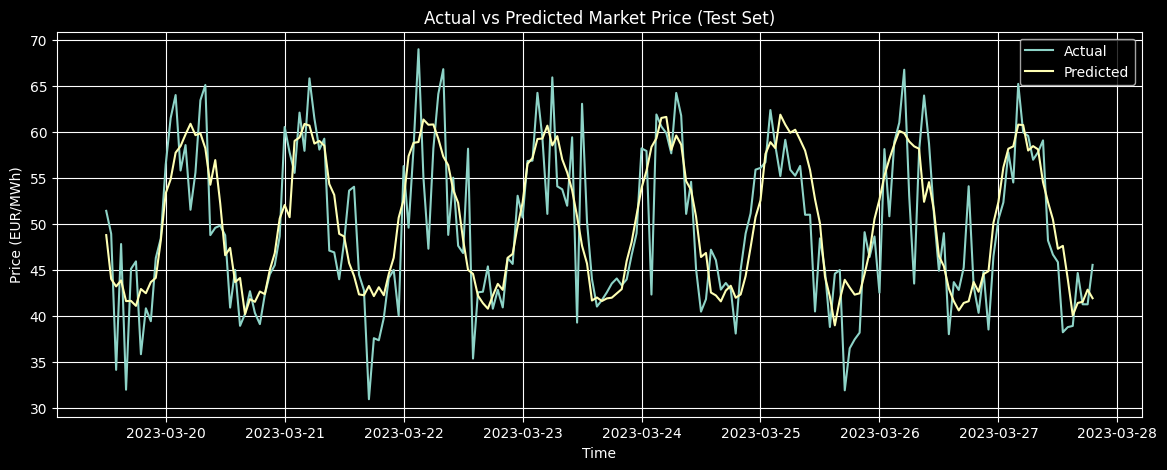

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], test_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Market Price (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)
plt.show()


## Step 27. Compare the baseline and the Gradient Boosting model

In this step, the baseline and the machine learning model are plotted together. This provides a direct visual comparison between the simple forecasting rule and the trained model.


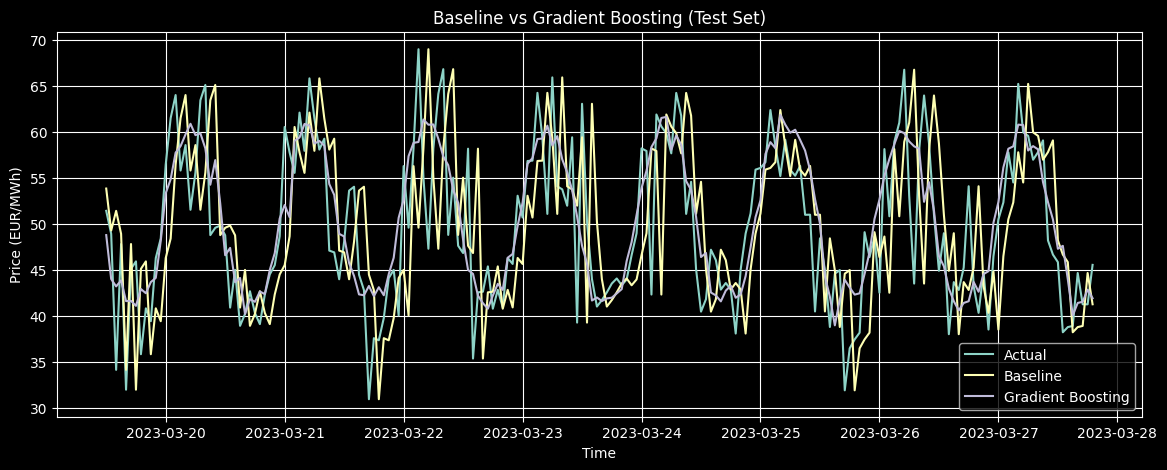

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], baseline_test_pred.iloc[:200], label="Baseline")
plt.plot(y_test.index[:200], test_pred[:200], label="Gradient Boosting")
plt.title("Baseline vs Gradient Boosting (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)
plt.show()


## Step 28. Display feature importance values

In this step, the feature importance values from the Gradient Boosting model are displayed. These values indicate which variables contribute the most to the predictions.


In [29]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

print(importances)


hour                   0.603230
hour_sin               0.233363
hour_cos               0.030083
demand_lag_1           0.020971
price_lag_24           0.015728
demand_mw              0.015052
price_roll_std_24      0.013667
price_lag_1            0.012518
temperature            0.012499
demand_roll_mean_24    0.010761
price_lag_168          0.009656
demand_lag_24          0.009418
price_roll_mean_24     0.005794
day_of_week            0.003019
dow_sin                0.001518
month                  0.001464
dow_cos                0.001165
is_weekend             0.000095
dtype: float64


## Step 29. Visualize feature importance

In this step, the most important features are plotted. This makes the model behavior easier to interpret and helps explain the drivers of electricity market prices in the sample project.


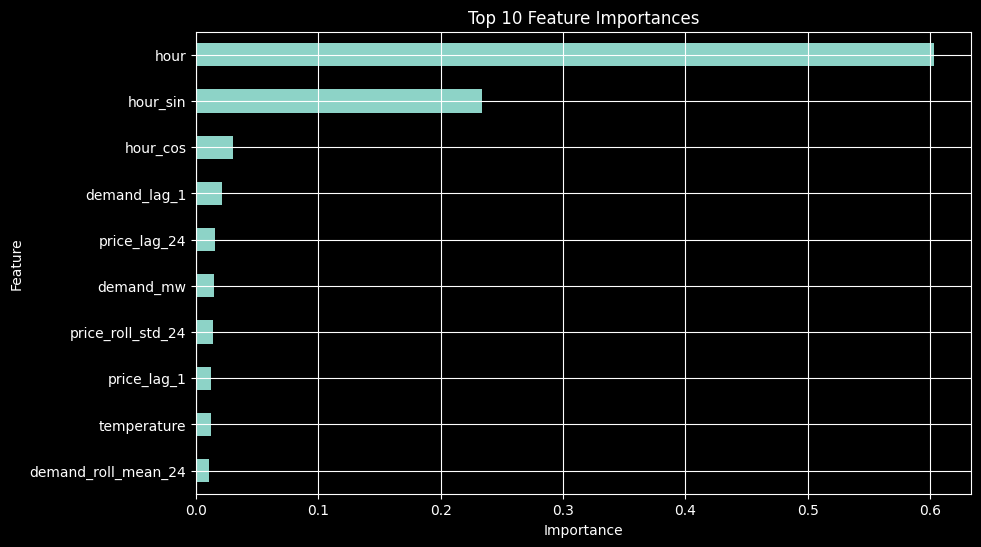

In [30]:
plt.figure(figsize=(10, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


## Step 30. Calculate MAPE as an additional metric

In this step, the mean absolute percentage error is calculated. This expresses the prediction error in relative percentage terms. A small constant is included to avoid division by zero.


In [31]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_test = mean_absolute_percentage_error(y_test, test_pred)
print(f"Test MAPE: {mape_test:.2f}%")


Test MAPE: 8.36%


## Step 31. Save the prediction results to a CSV file

In this step, the actual values and the predictions are saved to a CSV file. This is useful for further analysis, reporting, or creating external visualizations.


In [32]:
results_df = pd.DataFrame({
    "timestamp": y_test.index,
    "actual_price": y_test.values,
    "baseline_prediction": baseline_test_pred.values,
    "gb_prediction": test_pred
})

results_df.to_csv("market_price_prediction_results.csv", index=False)
print("Results saved to market_price_prediction_results.csv")


Results saved to market_price_prediction_results.csv
